In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Convert Fare from string to float if needed
if df['Fare'].dtype == 'object':
    df['Fare'] = df['Fare'].str.replace(',', '').astype(float)


In [3]:
# Remove invalid ages (e.g., negative or extremely high)
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]


In [4]:
# Validate Embarked values
valid_ports = ['C', 'Q', 'S']
df = df[df['Embarked'].isin(valid_ports)]


In [5]:
# Validate Ticket format (example: remove tickets with only digits or too short)
df = df[df['Ticket'].astype(str).str.len() >= 4]


In [6]:
# Example: Ensure Fare is positive
df = df[df['Fare'] > 0]


## Filtering Data

In [7]:
df.drop_duplicates(inplace=True)


In [8]:
# Filter passengers in 1st class
df_first_class = df[df['Pclass'] == 1]

# Filter passengers older than 18
df_adults = df[df['Age'] >= 18]


In [9]:
df_filtered = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]


In [10]:
# Survival rate by class
survival_rate = df.groupby('Pclass')['Survived'].mean().reset_index()
print(survival_rate)


   Pclass  Survived
0       1  0.670391
1       2  0.479769
2       3  0.239316


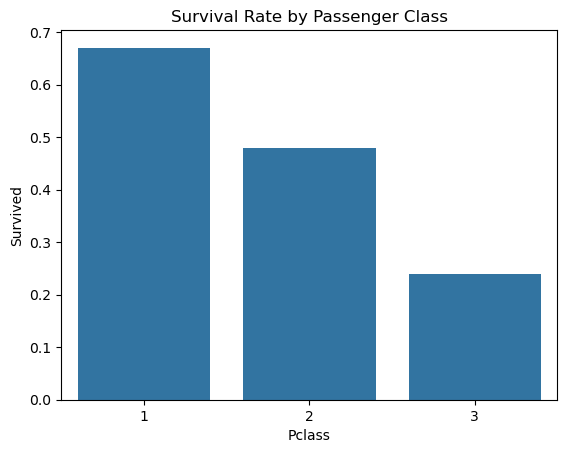

In [11]:
sns.barplot(x='Pclass', y='Survived', data=survival_rate)
plt.title("Survival Rate by Passenger Class")
plt.show()
